# Academic Paper Recommendation

## 1. Introduction

This study investigates academic paper recommendation using a fixed dataset pipeline generated from arXiv and OpenAlex sources. The `academic-paper-recommendation.ipynb` notebook focuses on downstream implementation and evaluation: data loading, exploration, cleaning, preprocessing/indexing, embedding, evaluation with standard IR metrics, and embedding geometry analysis.

### Objectives

1. Define and justify a methodology for building a domain-specific AI/ML corpus from arXiv.
2. Construct and document an enrichment workflow using OpenAlex metadata and citation signals.
3. Analyse data quality and corpus characteristics to identify strengths, biases, and risks to validity.
4. Build query and qrels resources suitable for reproducible offline evaluation.
5. Implement and evaluate recommendation approaches using standard IR metrics and comparative analysis.
6. Provide critical appraisal of outcomes, limitations, and actionable directions for further work.

In [44]:
# =========================================================
# Import required libraries
# =========================================================
%pip install matplotlib pandas
import json
import os
import time
import math
import gc
from collections import Counter, defaultdict
from dataclasses import dataclass, asdict
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.


In [45]:
# =========================================================
# Configuration
# =========================================================

DATA_DIR = "data"
OUTPUT_DIR = "outputs"
FIGURES_DIR = os.path.join(OUTPUT_DIR, "figures")
TABLES_DIR = os.path.join(OUTPUT_DIR, "tables")
METRICS_DIR = os.path.join(OUTPUT_DIR, "metrics")

PAPERS_PATH = os.path.join(DATA_DIR, "openalex_enriched.jsonl")
DATASET_METADATA_PATH = os.path.join(DATA_DIR, "dataset_metadata.json")
QUERIES_PATH = os.path.join(DATA_DIR, "queries.jsonl")
QRELS_PATH = os.path.join(DATA_DIR, "qrels.jsonl")

SBERT_MODEL_NAME = "all-MiniLM-L6-v2"
TOP_K_VALUES = [5, 10, 20]
RANDOM_SEED = 70

HYBRID_ALPHA = 0.5
TWO_STAGE_CANDIDATE_SIZE = 100

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(TABLES_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)

## 2. Utilities

In [46]:
def load_jsonl(path: str) -> List[Dict]:
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records

def load_json(path: str) -> Dict:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def save_json(data: Dict, path: str) -> None:
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2, ensure_ascii=False)


def save_dataframe(df: pd.DataFrame, path: str) -> None:
    df.to_csv(path, index=False)


def normalise_whitespace(text: str) -> str:
    return " ".join(text.split()).strip()

## 3. Data Loading

In [47]:

print("Loading data...")
papers = load_jsonl(PAPERS_PATH)
queries = load_jsonl(QUERIES_PATH)
qrels = load_jsonl(QRELS_PATH)
dataset_metadata = load_json(DATASET_METADATA_PATH)
print("Data loaded successfully.")



Loading data...
Data loaded successfully.


## 4. Data Exploration

**Purpose:** This section validates the quality, structure, and suitability of the dataset before model development and evaluation. It provides evidence on corpus composition, enrichment reliability, citation signal characteristics, and potential risks (e.g., imbalance, sparsity, duplicates) so that later retrieval results can be interpreted critically and reproducibly.


### 4.1 Category Distribution

**Justification:** Category balance affects retrieval fairness and interpretation of model performance. This analysis shows whether one research area dominates the corpus.


Category distribution:


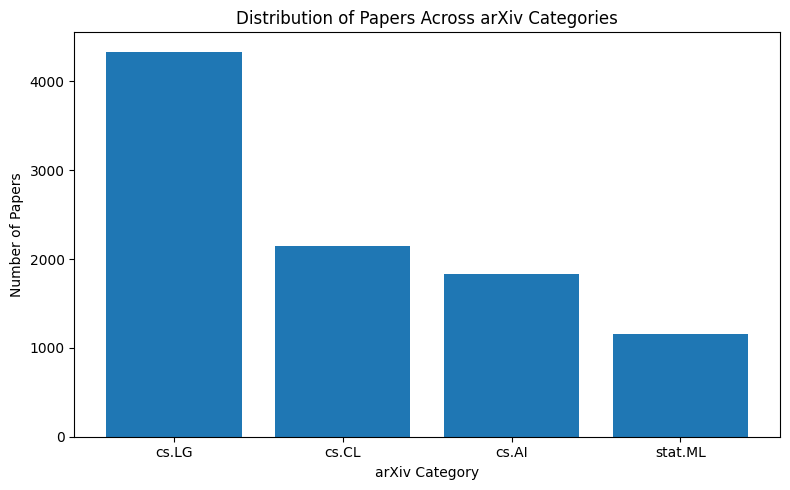

In [48]:
categories = [p["primary_category"] for p in papers]

# Category distribution
print("Category distribution:")
category_counts = dataset_metadata.get("category_counts", {})
plt.figure(figsize=(8, 5))
plt.bar(category_counts.keys(), category_counts.values())
plt.xlabel("arXiv Category")
plt.ylabel("Number of Papers")
plt.title("Distribution of Papers Across arXiv Categories")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "category_distribution.png"), dpi=300)
plt.show()
plt.close()

### 4.2 Abstract Length Distribution

**Justification:** Abstract length influences text representation quality and can bias embedding-based retrieval. This helps validate preprocessing and model input assumptions.

Abstract length distribution:


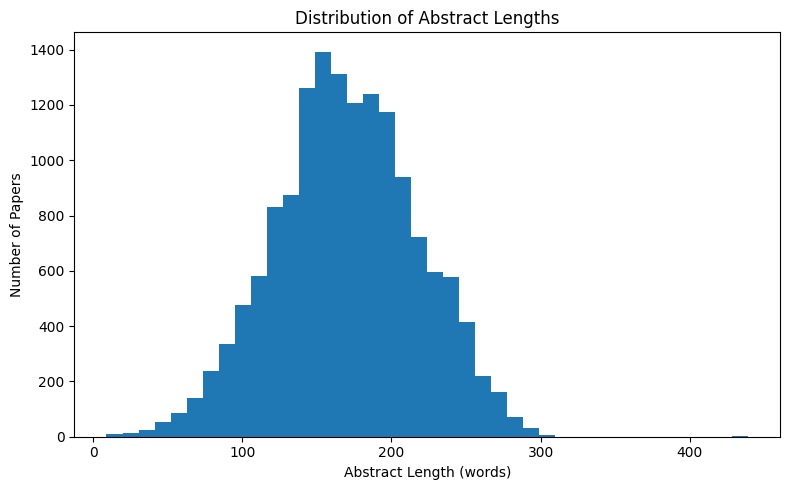

In [49]:
abstract_lengths = [len(p["abstract"].split()) for p in papers]

# Abstract length distribution
print("Abstract length distribution:")
plt.figure(figsize=(8, 5))
plt.hist(abstract_lengths, bins=40)
plt.xlabel("Abstract Length (words)")
plt.ylabel("Number of Papers")
plt.title("Distribution of Abstract Lengths")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "abstract_length_distribution.png"), dpi=300)
plt.show()
plt.close()

### 4.3 Corpus Summary Statistics

**Justification:** High-level corpus statistics provide a compact quality check and establish reproducible baseline characteristics for later experiments.

In [50]:

# Save corpus summary table
summary = pd.DataFrame([
    {"Statistic": "Corpus size", "Value": len(papers)},
    {"Statistic": "Average abstract length", "Value": round(np.mean(abstract_lengths), 2)},
    {"Statistic": "Median abstract length", "Value": round(np.median(abstract_lengths), 2)},
    {"Statistic": "Vocabulary proxy (unique categories)", "Value": len(set(categories))}
])
print("Corpus summary:")
print(summary)
save_dataframe(summary, os.path.join(TABLES_DIR, "corpus_summary.csv"))

Corpus summary:
                              Statistic     Value
0                           Corpus size  15000.00
1               Average abstract length    169.89
2                Median abstract length    169.00
3  Vocabulary proxy (unique categories)    119.00


### 4.4 Data Quality Audit

**Justification:** Missing and invalid values directly affect matching quality, retrieval performance, and reproducibility. Auditing key fields quantifies data reliability before modeling.

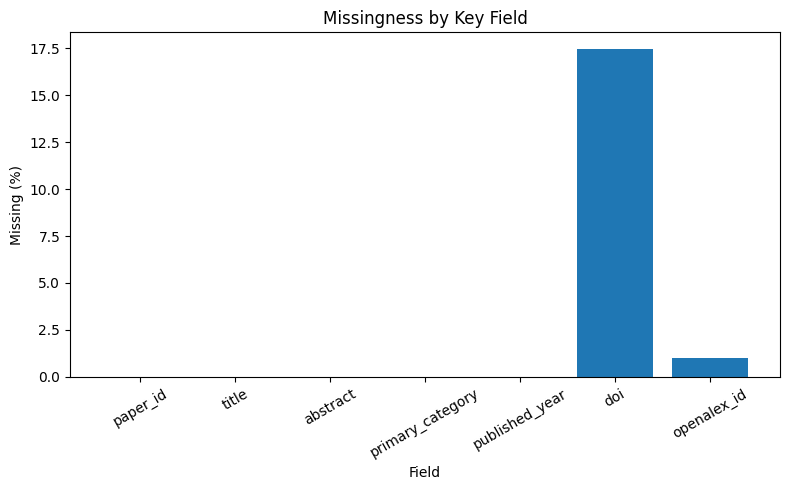

In [51]:
OPENALEX_META_PATH = os.path.join(DATA_DIR, "openalex_enrichment_metadata.json")

papers_df = pd.DataFrame(papers)
queries_df = pd.DataFrame(queries)
qrels_df = pd.DataFrame(qrels)

required_fields = ["paper_id", "title", "abstract", "primary_category", "published_year", "doi", "openalex_id"]
quality_rows = []

for field in required_fields:
    if field not in papers_df.columns:
        missing_count = len(papers_df)
    else:
        series = papers_df[field]
        if field in ["paper_id", "title", "abstract", "primary_category", "doi", "openalex_id"]:
            missing_count = int(series.isna().sum() + series.astype(str).str.strip().eq("").sum())
        else:
            missing_count = int(series.isna().sum())

    quality_rows.append({
        "field": field,
        "missing_count": missing_count,
        "missing_percent": round((missing_count / len(papers_df)) * 100, 2) if len(papers_df) else 0,
    })

quality_df = pd.DataFrame(quality_rows)

eligible_mask = (
    papers_df.get("paper_id", pd.Series([""] * len(papers_df))).astype(str).str.strip().ne("")
    & papers_df.get("title", pd.Series([""] * len(papers_df))).astype(str).str.strip().ne("")
    & papers_df.get("abstract", pd.Series([""] * len(papers_df))).astype(str).str.strip().ne("")
)

cleaning_summary_df = pd.DataFrame([
    {"metric": "raw_records", "value": int(len(papers_df))},
    {"metric": "records_after_cleaning_rules", "value": int(eligible_mask.sum())},
    {"metric": "dropped_by_cleaning_rules", "value": int((~eligible_mask).sum())},
    {
        "metric": "drop_rate_percent",
        "value": round((((~eligible_mask).sum() / len(papers_df)) * 100), 2) if len(papers_df) else 0,
    },
])

save_dataframe(quality_df, os.path.join(TABLES_DIR, "data_quality_summary.csv"))
save_dataframe(cleaning_summary_df, os.path.join(TABLES_DIR, "cleaning_summary.csv"))

plt.figure(figsize=(8, 5))
plt.bar(quality_df["field"], quality_df["missing_percent"])
plt.xlabel("Field")
plt.ylabel("Missing (%)")
plt.title("Missingness by Key Field")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "missingness_by_field.png"), dpi=300)
plt.show()
plt.close()

### 4.5 OpenAlex Enrichment Quality

**Justification:** Recommendation quality depends on enrichment coverage. This analysis evaluates match success, failure modes, and enrichment confidence.

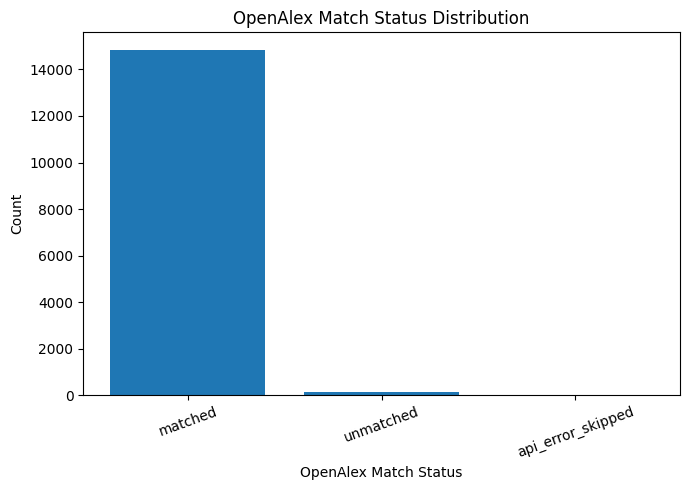

In [52]:
status_series = papers_df.get("openalex_match_status", pd.Series(["missing"] * len(papers_df)))
status_counts = status_series.fillna("missing").value_counts().sort_values(ascending=False)
status_df = pd.DataFrame({"openalex_match_status": status_counts.index, "count": status_counts.values})
save_dataframe(status_df, os.path.join(TABLES_DIR, "openalex_match_status_counts.csv"))

if os.path.exists(OPENALEX_META_PATH):
    openalex_meta = load_json(OPENALEX_META_PATH)
    enrichment_quality_df = pd.DataFrame([
        {"metric": "matched_by_doi", "value": openalex_meta.get("matched_by_doi", 0)},
        {"metric": "matched_by_title", "value": openalex_meta.get("matched_by_title", 0)},
        {"metric": "unmatched", "value": openalex_meta.get("unmatched", 0)},
        {"metric": "api_errors_skipped", "value": openalex_meta.get("api_errors_skipped", 0)},
        {"metric": "match_rate", "value": openalex_meta.get("match_rate", 0)},
    ])
    save_dataframe(enrichment_quality_df, os.path.join(TABLES_DIR, "openalex_enrichment_quality.csv"))

plt.figure(figsize=(7, 5))
plt.bar(status_df["openalex_match_status"], status_df["count"])
plt.xlabel("OpenAlex Match Status")
plt.ylabel("Count")
plt.title("OpenAlex Match Status Distribution")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "openalex_match_status_distribution.png"), dpi=300)
plt.show()
plt.close()

### 4.6 Citation Structure Analysis

**Justification:** Citation-based signals support relevance modeling and query generation. Understanding citation distributions helps justify their use and limitations.

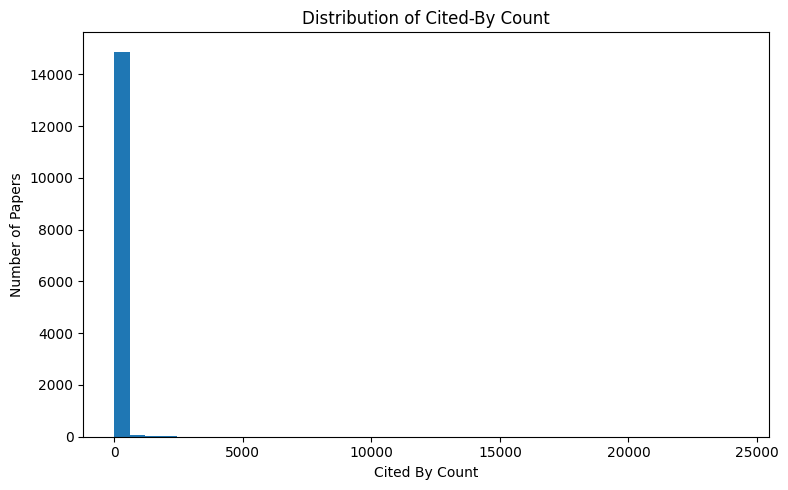

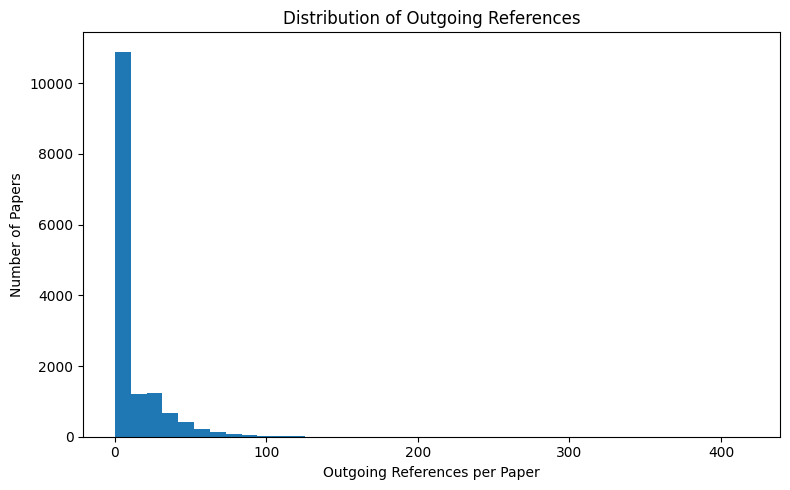

In [53]:
cited_by = pd.to_numeric(papers_df.get("cited_by_count", pd.Series([0] * len(papers_df))), errors="coerce").fillna(0)
outgoing_refs = papers_df.get("referenced_works", pd.Series([[]] * len(papers_df))).apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

citation_summary_df = pd.DataFrame([
    {"metric": "avg_cited_by_count", "value": round(float(cited_by.mean()), 2)},
    {"metric": "median_cited_by_count", "value": round(float(cited_by.median()), 2)},
    {"metric": "p90_cited_by_count", "value": round(float(np.percentile(cited_by, 90)), 2) if len(cited_by) else 0},
    {"metric": "avg_outgoing_references", "value": round(float(outgoing_refs.mean()), 2)},
    {"metric": "median_outgoing_references", "value": round(float(outgoing_refs.median()), 2)},
])
save_dataframe(citation_summary_df, os.path.join(TABLES_DIR, "citation_summary.csv"))

plt.figure(figsize=(8, 5))
plt.hist(cited_by, bins=40)
plt.xlabel("Cited By Count")
plt.ylabel("Number of Papers")
plt.title("Distribution of Cited-By Count")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "cited_by_count_distribution.png"), dpi=300)
plt.show()
plt.close()

plt.figure(figsize=(8, 5))
plt.hist(outgoing_refs, bins=40)
plt.xlabel("Outgoing References per Paper")
plt.ylabel("Number of Papers")
plt.title("Distribution of Outgoing References")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "outgoing_references_distribution.png"), dpi=300)
plt.show()
plt.close()

### 4.7 Query and Qrels Diagnostics

**Justification:** Retrieval evaluation quality depends on query relevance density. This section checks whether the benchmark is informative and not overly sparse.

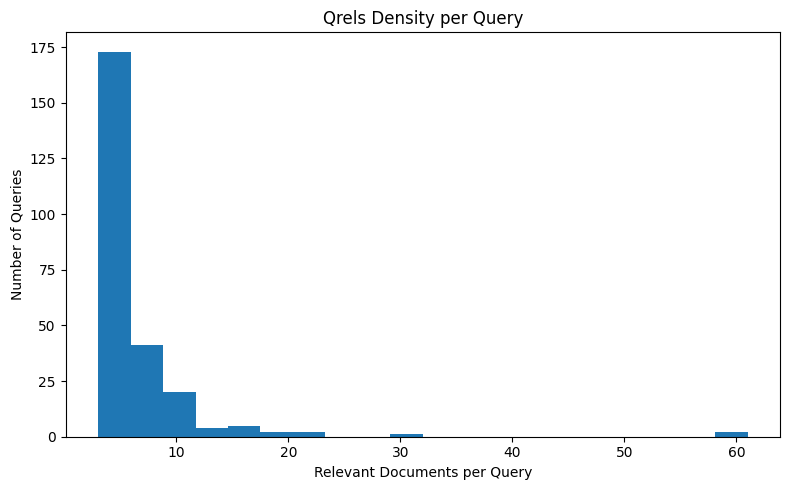

In [54]:
qrels_per_query = qrels_df.groupby("query_id")["doc_id"].nunique().sort_values(ascending=False)
qrels_summary_df = pd.DataFrame([
    {"metric": "num_queries", "value": int(queries_df["query_id"].nunique() if "query_id" in queries_df else 0)},
    {"metric": "num_qrels_pairs", "value": int(len(qrels_df))},
    {"metric": "avg_relevant_docs_per_query", "value": round(float(qrels_per_query.mean()), 2) if len(qrels_per_query) else 0},
    {"metric": "median_relevant_docs_per_query", "value": round(float(qrels_per_query.median()), 2) if len(qrels_per_query) else 0},
    {"metric": "queries_with_<=3_relevant_docs", "value": int((qrels_per_query <= 3).sum()) if len(qrels_per_query) else 0},
])
save_dataframe(qrels_summary_df, os.path.join(TABLES_DIR, "qrels_summary.csv"))

plt.figure(figsize=(8, 5))
plt.hist(qrels_per_query.values, bins=20)
plt.xlabel("Relevant Documents per Query")
plt.ylabel("Number of Queries")
plt.title("Qrels Density per Query")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "qrels_per_query_distribution.png"), dpi=300)
plt.show()
plt.close()

### 4.8 Class Imbalance and Duplicate Checks

**Justification:** Imbalance and duplicates can bias evaluation and inflate apparent performance. These checks support critical discussion of dataset threats to validity.

In [55]:
cat_counts = pd.Series(dataset_metadata.get("category_counts", {}), dtype="float64")
imbalance_ratio = round(float(cat_counts.max() / cat_counts.min()), 3) if len(cat_counts) and cat_counts.min() > 0 else np.nan

norm_titles = papers_df.get("title", pd.Series([""] * len(papers_df))).fillna("").astype(str).str.lower()
norm_titles = norm_titles.str.replace(r"\s+", " ", regex=True).str.strip()

doi_series = papers_df.get("doi", pd.Series([""] * len(papers_df))).fillna("").astype(str).str.lower().str.strip()
doi_series = doi_series.str.replace("https://doi.org/", "", regex=False)
doi_series = doi_series.str.replace("http://doi.org/", "", regex=False)
doi_series = doi_series.str.replace("doi.org/", "", regex=False)
non_empty_doi = doi_series[doi_series.ne("")]

imbalance_duplicate_df = pd.DataFrame([
    {"metric": "category_imbalance_ratio_max_over_min", "value": imbalance_ratio},
    {"metric": "duplicate_titles_exact_count", "value": int(norm_titles.duplicated().sum())},
    {"metric": "duplicate_doi_exact_count", "value": int(non_empty_doi.duplicated().sum())},
])
print("Imbalance and duplicates summary:")
print(imbalance_duplicate_df)
save_dataframe(imbalance_duplicate_df, os.path.join(TABLES_DIR, "imbalance_and_duplicates_summary.csv"))

print("Section 4 exploration outputs saved to outputs/figures and outputs/tables.")

Imbalance and duplicates summary:
                                  metric  value
0  category_imbalance_ratio_max_over_min   3.75
1           duplicate_titles_exact_count   4.00
2              duplicate_doi_exact_count   4.00
Section 4 exploration outputs saved to outputs/figures and outputs/tables.


## 5. Data Cleaning

In [56]:
cleaned = []

for p in papers:
    title = normalise_whitespace(p.get("title", ""))
    abstract = normalise_whitespace(p.get("abstract", ""))
    primary_category = p.get("primary_category", "")
    paper_id = p.get("paper_id", "")

    if not paper_id or not title or not abstract:
        continue

    cleaned.append({
        **p,
        "title": title,
        "abstract": abstract,
        "primary_category": primary_category,
        "text": f"{title} {abstract}".strip()
    })